# 06. From a Locked Score to a Testable Intervention Plan

**Project:** Customer Churn Prediction & Lifetime Value.

**This notebook covers:**
1. An independent audit of the locked rule's action plan -- recomputing flags from
   scratch and checking they match notebook 5's saved results exactly
2. Who the plan actually asks the business to contact, and what it would cost
3. A retrospective look at where the false-negative proxy loss concentrates, using test
   labels for auditing only -- never for retargeting
4. A sensitivity check on the margin and price assumptions
5. The design for the prospective experiment this whole pipeline has been building
   toward -- because nothing in this project measures whether an intervention actually
   works

**Question:** what would the validation-selected policy ask a business to do, what
would it cost under the stated assumptions, and what experiment would tell us whether
it's worth doing? Test labels appear in this notebook only as a retrospective audit of
a rule that was already frozen in notebook 5 -- at no point does anything here get to
change who's targeted.

**A note on where this notebook sits relative to the source articles.** Oliveira's
article ("Your Churn Threshold Is a Pricing Decision") names segment-aware
false-positive pricing as its own explicit next step, and in the first iteration of
this project that step genuinely happened here, in notebook 6, one notebook later than
the article's own scope. This iteration folds it into notebook 5 instead, so by the
time this notebook starts, that recommendation is already fulfilled rather than
introduced. What this notebook adds instead -- turning a flagged list into a concrete
per-customer action, and then a prospective experiment -- is closer to the territory
Katherine Munro's "Congrats on Your CLV Prediction Model, Now What" covers (loyalty
nudges, retention targeting, turning a prediction into a business action), though that
article is a much thinner, more general influence here than Oliveira's is on notebook
5: it motivates the general idea of acting on a score, not any specific mechanic used
below.

### Import necessary libraries

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [2]:
# Resolve repository paths whether Jupyter is launched from the
# repository root or from the notebooks directory.
REPO_ROOT = Path.cwd()

if not (REPO_ROOT / 'data').exists():
    REPO_ROOT = REPO_ROOT.parent

RAW_DATA = REPO_ROOT / 'data' / 'raw'
PROCESSED_DATA = REPO_ROOT / 'data' / 'processed'

### Reproducing the price/loss functions independently

The same `INTERVENTIONS` table and `price()` function from notebook 5, reproduced here
rather than imported, specifically so this notebook's action plan is an **independent
recomputation** -- not just a re-display of whatever notebook 5 already saved. If a
mistake had crept into either notebook, recomputing from the frozen policy and raw
probabilities, and then asserting the two agree, is what would catch it.

In [3]:
INTERVENTIONS = {
    "Champions":                    ("Loyalty/bundle upgrade, dedicated outreach", 40.),
    "Churn Risk (high value)":      ("Proactive outreach", 35.),
    "Loyal Customers":              ("Personalized email and modest incentive", 20.),
    "Potential Loyalists":          ("Standard discount code", 15.),
    "At Risk":                      ("Discount and re-engagement email", 15.),
    "Recent, Low Engagement":       ("Light nudge email", 8.),
    "Needs Attention":              ("Light nudge email", 8.),
    "Lost / Lowest Priority":       ("Automated low-cost email", 5.),
    "High-Value Infrequent Buyers": ("Standard discount code", 15.),
}

def price(df: pd.DataFrame, threshold: float, proba_col: str, *,
         margin_multiplier: float = 1.0, action_multiplier: float = 1.0):
    z = df.copy()
    z["flagged"] = z[proba_col].ge(threshold).astype(int)
    z["is_fp"] = z["flagged"].eq(1) & z["churned"].eq(0)
    z["is_fn"] = z["flagged"].eq(0) & z["churned"].eq(1)
    z["fp_loss"] = z["is_fp"] * z["action_cost"] * action_multiplier
    z["fn_loss"] = z["is_fn"] * z["fn_cost_illustrative"] * margin_multiplier
    z["intervention_spend"] = z["flagged"] * z["action_cost"] * action_multiplier
    z["decision_loss"] = z["fp_loss"] + z["fn_loss"]
    result = {"n": len(z), "flagged": int(z["flagged"].sum()), "fp": int(z["is_fp"].sum()),
              "fn": int(z["is_fn"].sum()), "fp_loss": float(z["fp_loss"].sum()),
              "fn_loss": float(z["fn_loss"].sum()), "decision_loss": float(z["decision_loss"].sum()),
              "all_flagged_spend": float(z["intervention_spend"].sum())}
    return result, z

## 1. Read the frozen decision and its test audit

In [4]:
with (PROCESSED_DATA / "retail_locked_policy.json").open() as f:
    policy = json.load(f)
test_decisions = pd.read_parquet(PROCESSED_DATA / "retail_test_decisions.parquet")
test_comparison = pd.read_parquet(PROCESSED_DATA / "retail_test_policy_comparison.parquet")

assert set(test_decisions["split"]) == {"test"} and test_decisions["CustomerID"].is_unique
assert policy["selection_population"] == "validation" and policy["evaluation_population"] == "test"
print(f"Locked policy: {policy['model']} at threshold {policy['threshold']}")
print(f"Test customers: {len(test_decisions):,}")

Locked policy: gbc at threshold 0.09
Test customers: 386


## 2. Map flagged customers to proposed actions

Every eligible segment needs an explicit action and price -- there's no fallback
"default" intervention, by design, so a segment silently missing from `INTERVENTIONS`
raises an error rather than getting an arbitrary cost. The output below is a proposed
contact list for a future trial, not evidence that contacting anyone on it actually
prevents them from churning.

In [5]:
model_col = f"proba_{policy['model']}"
recomputed_flags = test_decisions[model_col].ge(policy["threshold"]).astype(int)
assert recomputed_flags.eq(test_decisions["flagged"]).all(), "independent recomputation disagrees with notebook 5"

expected_cost = test_decisions["segment"].map(lambda s: INTERVENTIONS[s][1])
assert np.allclose(test_decisions["action_cost"], expected_cost)

metrics, priced = price(test_decisions, policy["threshold"], model_col)
locked_row = test_comparison.loc[test_comparison["policy"].eq("locked_segment")].iloc[0]
for col in ["n", "flagged", "fp", "fn", "fp_loss", "fn_loss", "decision_loss", "all_flagged_spend"]:
    assert np.isclose(metrics[col], locked_row[col]), f"{col} disagrees with notebook 5's saved result"
print("Independent recomputation matches notebook 5's saved test result on every field.")

Independent recomputation matches notebook 5's saved test result on every field.


In [6]:
plan = priced.loc[priced["flagged"].eq(1),
                  ["CustomerID", "segment", model_col, "intervention", "action_cost"]].copy()
plan = plan.rename(columns={model_col: "predicted_churn_probability"})
assert len(plan) == metrics["flagged"] and plan["CustomerID"].is_unique
assert np.isclose(plan["action_cost"].sum(), metrics["all_flagged_spend"])

print(f"Actions proposed: {len(plan):,} of {len(test_decisions):,} test customers "
      f"({len(plan)/len(test_decisions)*100:.1f}%)")
print(f"Assumed total intervention spend: £{plan['action_cost'].sum():,.2f}")
plan.groupby(["segment", "intervention"]).agg(customers=("CustomerID", "size"), spend=("action_cost", "sum"))

Actions proposed: 306 of 386 test customers (79.3%)
Assumed total intervention spend: £3,622.00


,,customers,spend
segment,intervention,,
At Risk,Discount and re-engagement email,16,240.0
Champions,"Loyalty/bundle upgrade, dedicated outreach",1,40.0
Churn Risk (high value),Proactive outreach,11,385.0
High-Value Infrequent Buyers,Standard discount code,38,570.0
Lost / Lowest Priority,Automated low-cost email,76,380.0
Loyal Customers,Personalized email and modest incentive,48,960.0
Needs Attention,Light nudge email,40,320.0
Potential Loyalists,Standard discount code,17,255.0
"Recent, Low Engagement",Light nudge email,59,472.0


The locked rule proposes an action for **306 of 386 test customers (79.3%)**,
implying **£3,622** in assumed total spend. That 79.3% flag rate is a direct consequence
of notebook 5's cost structure, not a modeling defect: with false negatives priced far
above false positives, the loss-minimizing rule casts a wide net almost by design.
Worth keeping the two spend concepts distinct here -- the **false-positive loss**
component from notebook 5 only counts flagged customers who turn out not to have
churned, while **assumed total spend** (shown above) prices every flagged customer,
churner or not, since an intervention gets sent to whoever the rule flags regardless of
what they actually go on to do.

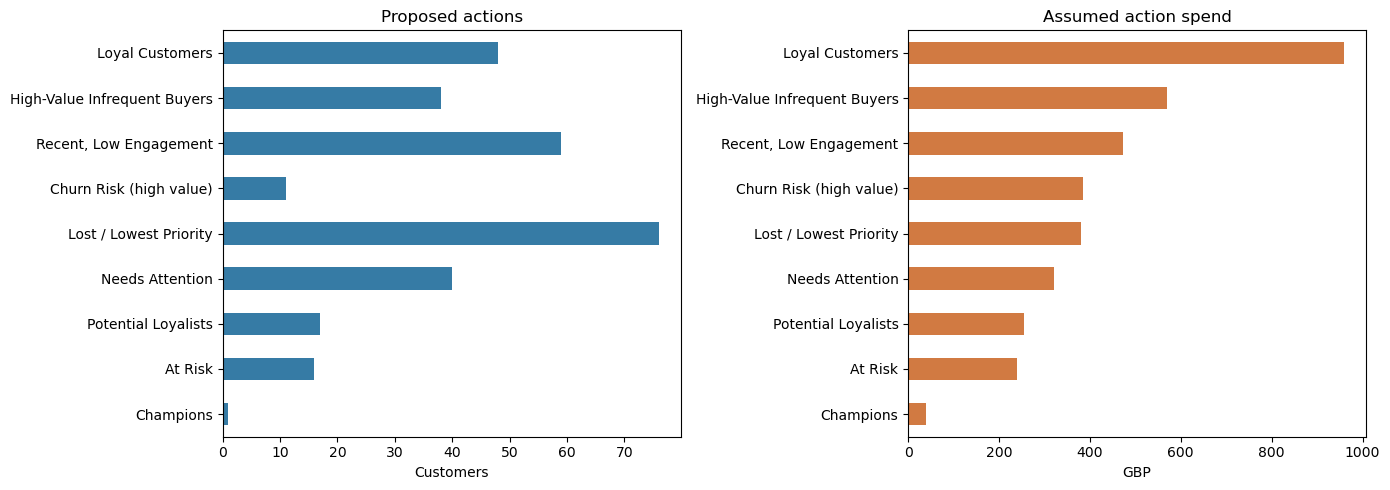

In [7]:
by_segment = plan.groupby("segment")["action_cost"].agg(customers="size", spend="sum").sort_values("spend")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
by_segment["customers"].plot.barh(ax=axes[0], color="#367ba5", title="Proposed actions")
by_segment["spend"].plot.barh(ax=axes[1], color="#d17a42", title="Assumed action spend")
axes[0].set_xlabel("Customers"); axes[1].set_xlabel("GBP")
for ax in axes: ax.set_ylabel("")
fig.tight_layout(); plt.show(); plt.close(fig)

**Reading the action and spend charts.** Lost / Lowest Priority has the most
flagged customers (**76**) but only **£380** in assumed spend, at £5 each. Loyal
Customers has fewer flags (**48**) yet the largest total assumed spend (**£960**), at
£20 each. Volume and budget genuinely pull in different directions here -- a plan
reviewed only by headcount, or only by budget, would tell two different stories.

## 3. Retrospective audit and assumption sensitivity

Everything below uses test labels **after** targeting, purely to describe what
happened to this held-out sample. None of it feeds back into who gets contacted --
that would defeat the entire point of freezing the rule in notebook 5 -- and several
segments here are small enough that a segment-specific effect claim wouldn't be
credible even if the label had been available at targeting time.

In [8]:
audit = priced.groupby("segment").agg(
    n=("CustomerID", "size"), churn_rate=("churned", "mean"), flagged=("flagged", "sum"),
    fp=("is_fp", "sum"), fn=("is_fn", "sum"), unit_cost=("action_cost", "first"),
    fp_cost=("fp_loss", "sum"), fn_cost=("fn_loss", "sum"),
    all_flagged_spend=("intervention_spend", "sum")).reset_index()
assert np.allclose(audit["fp_cost"], audit["fp"] * audit["unit_cost"])
assert np.isclose(audit["fp_cost"].sum() + audit["fn_cost"].sum(), metrics["decision_loss"])
audit.sort_values("fp_cost", ascending=False)

,segment,n,churn_rate,flagged,fp,fn,unit_cost,fp_cost,fn_cost,all_flagged_spend
5,Loyal Customers,83,0.120482,48,40,2,20.0,800.0,1225.081102,960.0
3,High-Value Infrequent Buyers,38,0.421053,38,22,0,15.0,330.0,0.000000,570.0
2,Churn Risk (high value),13,0.153846,11,9,0,35.0,315.0,0.000000,385.0
8,"Recent, Low Engagement",59,0.423729,59,34,0,8.0,272.0,0.000000,472.0
7,Potential Loyalists,32,0.125000,17,15,2,15.0,225.0,1027.865356,255.0
6,Needs Attention,40,0.325000,40,27,0,8.0,216.0,0.000000,320.0
4,Lost / Lowest Priority,76,0.513158,76,37,0,5.0,185.0,0.000000,380.0
0,At Risk,16,0.375000,16,10,0,15.0,150.0,0.000000,240.0
1,Champions,29,0.034483,1,1,1,40.0,40.0,490.357277,40.0


In [9]:
for margin_mult, action_mult in [(0.5, 1), (1.5, 1), (1, 0.5), (1, 1.5)]:
    scenario, _ = price(test_decisions, policy["threshold"], model_col,
                        margin_multiplier=margin_mult, action_multiplier=action_mult)
    print(f"margin x{margin_mult}, action price x{action_mult}: "
          f"locked-rule loss = £{scenario['decision_loss']:,.2f}")

margin x0.5, action price x1: locked-rule loss = £3,904.65
margin x1.5, action price x1: locked-rule loss = £6,647.96
margin x1, action price x0.5: locked-rule loss = £4,009.80
margin x1, action price x1.5: locked-rule loss = £6,542.80


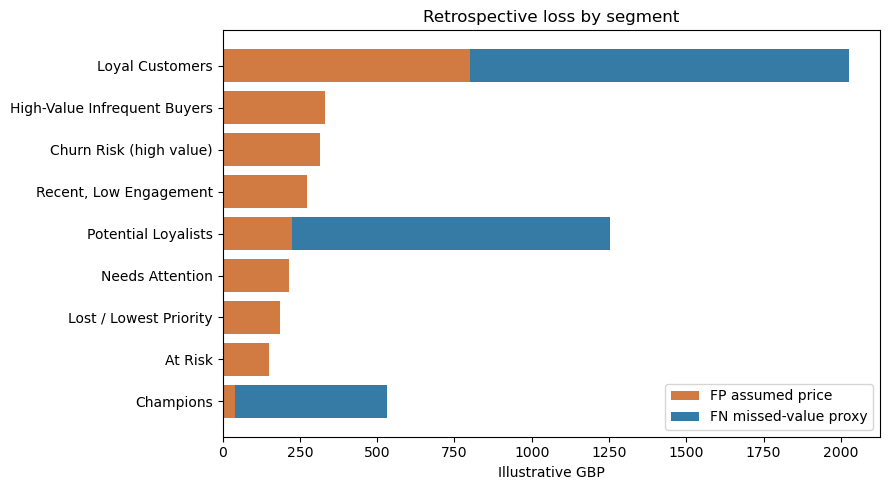

In [10]:
segment_loss = audit.sort_values("fp_cost")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(segment_loss["segment"], segment_loss["fp_cost"], color="#d17a42", label="FP assumed price")
ax.barh(segment_loss["segment"], segment_loss["fn_cost"], left=segment_loss["fp_cost"],
       color="#367ba5", label="FN missed-value proxy")
ax.set(title="Retrospective loss by segment", xlabel="Illustrative GBP")
ax.legend(); fig.tight_layout(); plt.show(); plt.close(fig)

**Reading retrospective segment loss.** Loyal Customers contribute the largest
proxy loss on test (**£2,025.08**), including **£1,225.08** from two missed churners.
Potential Loyalists add another **£1,252.87**, also mostly from two missed churners,
while Champions contribute **£530.36** from a single miss. Those five missed customers,
across three segments, account for the entire **£2,743.30** false-negative component of
the locked rule's test loss -- a small, specific set of misses, not a diffuse pattern
spread evenly across the flagged population. They describe this particular held-out
sample; they don't identify segments with any *proven* response to outreach, since no
outreach was actually sent.

**Sweeping the margin and price assumptions** moves the locked rule's test loss from
**£3,904.65** at half the assumed margin up to **£6,647.96** at 1.5x -- a wide enough
range that "how expensive was this policy" doesn't have a single answer independent of
the assumptions behind it. These are accounting sensitivities on the same fixed rule,
not a re-selection; notebook 5's paired validation-vs-test comparison is the place to
look for how the *choice* of rule responds to the same kind of uncertainty.

## 4. Designing the first real test

Nothing in this entire pipeline measures whether contacting a customer changes their
behavior -- every number so far is built from historical purchasing patterns and
assumed prices, never from an observed intervention response. The only way to close
that gap is a prospective, randomized test, designed and frozen *before* anyone acts on
it.

**Population.** Newly eligible repeat customers at a future decision date, scored using
only information available as of that date -- the same eligibility rule (at least two
distinct calibration invoices) applied going forward, not a re-use of this project's
historical customers.

**Randomization.** Within each segment the locked policy flags, randomly assign either
the segment's proposed intervention or a no-contact control. Randomizing *within*
segment, rather than across the whole flagged population, keeps the comparison fair
even though segments differ sharply in size and baseline value.

**Primary outcome.** Incremental gross contribution -- purchases and revenue in a
prespecified observation window, net of the *actually measured* intervention cost, not
the illustrative prices used throughout this project. Contact delivery and opt-out
rates should be tracked alongside the primary outcome, and the analysis should follow
intent-to-treat with proper uncertainty quantification, not just a raw before/after
comparison.

**What has to be frozen before enrollment starts:** eligibility rule, feature
definitions, the model and threshold, the action-to-segment mapping, the outcome
window, target sample size, and any stopping rules. If contact capacity is limited,
that constraint needs a prespecified allocation and monitoring plan decided in advance
-- not a decision to fall back on this project's retrospective test labels to hand-pick
who gets contacted first. And if a different threshold looks more promising after
seeing this project's numbers, that's a hypothesis for the *next* prospective
comparison, not a retroactive edit to this one.

## 5. Save the proposed action plan and audit

In [11]:
plan.to_parquet(PROCESSED_DATA / "retail_intervention_plan.parquet", index=False)
audit.to_parquet(PROCESSED_DATA / "retail_segment_audit.parquet", index=False)
print("Saved customer action plan and segment audit")

Saved customer action plan and segment audit


### Portfolio conclusion

This second iteration fixes the structural issue the first iteration's post-mortem
flagged as its most serious: **one canonical customer population and one decision
clock**, defined in notebook 2 and inherited unchanged by every notebook after it,
rather than each notebook computing its own version of "recent," "eligible," or
"churned." RFM segments are decision-time and train-fitted; the churn model trains on
calibration features only; the threshold is selected on validation and evaluated
exactly once on test; and every dollar figure in this pipeline -- the 25% margin, the
£5-£40 segment prices, the conditional-active spend proxy -- is labeled as the
illustrative assumption it is, not dressed up as a measured business outcome.

What this project has *not* done, at any point, is measure whether contacting a
customer changes what they do next. That's not a gap in the analysis -- it's the
honest boundary of what a purely historical dataset can tell you. The next real
question, and the one this notebook's experiment design exists to answer, is whether a
specific outreach action produces enough incremental value to clear its own real cost,
in a cohort that hasn't been observed yet.